# Preliminary Power Analysis

https://chatgpt.com/share/67b8dacb-66e4-8007-ba67-bb84cce97e77

In [ ]:
!pip install statsmodels stargazer
!pip install pingouin

In [ ]:
from statsmodels.stats.power import TTestIndPower
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from stargazer.stargazer import Stargazer
from statsmodels.stats.power import TTestIndPower
import pingouin as pg
from scipy import stats
import statsmodels.formula.api as smf
from statsmodels.stats.proportion import proportions_ztest

In [ ]:
n = TTestIndPower().solve_power(effect_size = .50,  # moderate statistical effect from ChatGPT
                            nobs1 = None, alpha = 0.05, power = 0.5, alternative='two-sided')

print(f"Necessary sample size: {np.ceil(n)}")

Necessary sample size: 32.0


# Data Prep

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# https://drive.google.com/file/d/1quEa3XdcaafIKuW7sesA0YrynkfV-K1p/view?usp=sharing
file_name = 'https://drive.google.com/uc?export=download&id=1quEa3XdcaafIKuW7sesA0YrynkfV-K1p'
#file_name ='https://drive.google.com/file/d/1Lujw4uLJEQo9Cm3ZyG7JrR-5dK4H3q7G/view?usp=drive_link'
df = pd.read_csv(file_name, skiprows = 1)
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Start Date,End Date,Response Type,IP Address,Progress,Duration (in seconds),Finished,Recorded Date,Response ID,Recipient Last Name,...,"If both sneakers were priced differently, which one would you buy at the following price points?","If both sneakers increased in value, which one would you be more likely to resell?","If you had to choose between these sneakers at the same price, which would you pick?",Which pair of sneakers are you more likely to purchase?.1,Which sneaker would you pay 20% more for if made with premium materials?.1,Which sneaker would you be more likely to pre-order or wait in line for?.1,"If you knew one of these sneakers was always available while the other had limited stock temporarily, which would you prefer?.1","If both sneakers were priced differently, which one would you buy at the following price points?.1","If both sneakers increased in value, which one would you be more likely to resell?.1","If you had to choose between these sneakers at the same price, which would you pick?.1"
0,"{""ImportId"":""startDate"",""timeZone"":""America/De...","{""ImportId"":""endDate"",""timeZone"":""America/Denv...","{""ImportId"":""status""}","{""ImportId"":""ipAddress""}","{""ImportId"":""progress""}","{""ImportId"":""duration""}","{""ImportId"":""finished""}","{""ImportId"":""recordedDate"",""timeZone"":""America...","{""ImportId"":""_recordId""}","{""ImportId"":""recipientLastName""}",...,"{""ImportId"":""QID7""}","{""ImportId"":""QID9""}","{""ImportId"":""QID10""}","{""ImportId"":""QID11""}","{""ImportId"":""QID12""}","{""ImportId"":""QID13""}","{""ImportId"":""QID14""}","{""ImportId"":""QID15""}","{""ImportId"":""QID16""}","{""ImportId"":""QID17""}"
1,2/26/25 12:17,2/26/25 12:17,Survey Preview,NaN,100,0,TRUE,2/26/25 12:17,R_7mVq1xhHO1fipwd,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2/26/25 12:20,2/26/25 12:20,Survey Preview,NaN,100,0,TRUE,2/26/25 12:20,R_7jcwc3SJNiDyOdM,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2/26/25 12:23,2/26/25 12:23,Survey Preview,NaN,100,0,TRUE,2/26/25 12:23,R_7qatSt57ojfK9nX,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2/26/25 12:25,2/26/25 12:25,Survey Preview,NaN,100,0,TRUE,2/26/25 12:25,R_7uFmHxBQAYnJ14d,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df = df.drop(index=0).reset_index(drop=True)
df.head()

,Start Date,End Date,Response Type,IP Address,Progress,Duration (in seconds),Finished,Recorded Date,Response ID,Recipient Last Name,...,"If both sneakers were priced differently, which one would you buy at the following price points?","If both sneakers increased in value, which one would you be more likely to resell?","If you had to choose between these sneakers at the same price, which would you pick?",Which pair of sneakers are you more likely to purchase?.1,Which sneaker would you pay 20% more for if made with premium materials?.1,Which sneaker would you be more likely to pre-order or wait in line for?.1,"If you knew one of these sneakers was always available while the other had limited stock temporarily, which would you prefer?.1","If both sneakers were priced differently, which one would you buy at the following price points?.1","If both sneakers increased in value, which one would you be more likely to resell?.1","If you had to choose between these sneakers at the same price, which would you pick?.1"
0,2/26/25 12:17,2/26/25 12:17,Survey Preview,NaN,100,0,TRUE,2/26/25 12:17,R_7mVq1xhHO1fipwd,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2/26/25 12:20,2/26/25 12:20,Survey Preview,NaN,100,0,TRUE,2/26/25 12:20,R_7jcwc3SJNiDyOdM,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2/26/25 12:23,2/26/25 12:23,Survey Preview,NaN,100,0,TRUE,2/26/25 12:23,R_7qatSt57ojfK9nX,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2/26/25 12:25,2/26/25 12:25,Survey Preview,NaN,100,0,TRUE,2/26/25 12:25,R_7uFmHxBQAYnJ14d,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2/26/25 12:25,2/26/25 12:25,Survey Preview,NaN,100,0,TRUE,2/26/25 12:25,R_7mekcaN57EdXXCO,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
print(df.columns)

Index(['Start Date', 'End Date', 'Response Type', 'IP Address', 'Progress',
       'Duration (in seconds)', 'Finished', 'Recorded Date', 'Response ID',
       'Recipient Last Name', 'Recipient First Name', 'Recipient Email',
       'External Data Reference', 'Location Latitude', 'Location Longitude',
       'Distribution Channel', 'User Language', 'Q_RecaptchaScore',
       'What is your gender ?',
       'Which pair of sneakers are you more likely to purchase?',
       'Which sneaker would you pay 20% more for if made with premium materials?',
       'Which sneaker would you be more likely to pre-order or wait in line for?',
       'If you knew one of these sneakers was always available while the other had limited stock temporarily, which would you prefer?',
       'If both sneakers were priced differently, which one would you buy at the following price points?',
       'If both sneakers increased in value, which one would you be more likely to resell?',
       'If you had to choose b

In [ ]:
df = df.drop(columns=['Start Date', 'End Date', 'Response Type', 'IP Address', 'Progress',
                      'Duration (in seconds)', 'Finished', 'Recorded Date', 'Recipient Last Name',
                      'Recipient First Name', 'Recipient Email','External Data Reference',
                      'Location Latitude', 'Location Longitude','Distribution Channel', 'User Language',
                      'Q_RecaptchaScore'])
df.head()

,Response ID,What is your gender ?,Which pair of sneakers are you more likely to purchase?,Which sneaker would you pay 20% more for if made with premium materials?,Which sneaker would you be more likely to pre-order or wait in line for?,"If you knew one of these sneakers was always available while the other had limited stock temporarily, which would you prefer?","If both sneakers were priced differently, which one would you buy at the following price points?","If both sneakers increased in value, which one would you be more likely to resell?","If you had to choose between these sneakers at the same price, which would you pick?",Which pair of sneakers are you more likely to purchase?.1,Which sneaker would you pay 20% more for if made with premium materials?.1,Which sneaker would you be more likely to pre-order or wait in line for?.1,"If you knew one of these sneakers was always available while the other had limited stock temporarily, which would you prefer?.1","If both sneakers were priced differently, which one would you buy at the following price points?.1","If both sneakers increased in value, which one would you be more likely to resell?.1","If you had to choose between these sneakers at the same price, which would you pick?.1"
0,R_7mVq1xhHO1fipwd,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,R_7jcwc3SJNiDyOdM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,R_7qatSt57ojfK9nX,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,R_7uFmHxBQAYnJ14d,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,R_7mekcaN57EdXXCO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124 entries, 0 to 123
Data columns (total 16 columns):
 #   Column                                                                                                                           Non-Null Count  Dtype 
---  ------                                                                                                                           --------------  ----- 
 0   Response ID                                                                                                                      124 non-null    object
 1   What is your gender ?                                                                                                            112 non-null    object
 2   Which pair of sneakers are you more likely to purchase?                                                                          57 non-null     object
 3   Which sneaker would you pay 20% more for if made with premium materials?                                 

Used ChatGPT to help with preprocessing. Link to chat: https://chatgpt.com/share/67c71188-eaa0-8007-9d55-47884e4a522f

In [ ]:
# used ChatGPT for guidance

df.rename(columns={"Response ID": "Response_ID"}, inplace=True)

# identify control and treatment columns
treatment_cols = [col for col in df.columns if col.endswith(".1")]
control_cols = [col for col in df.columns if col not in treatment_cols and col != "Response_ID"]

# gender mapping for both groups based on ID and group they belong to
gender_mapping = df.set_index("Response_ID")["What is your gender ?"].to_dict()

# rename control group columns (remove ".1" suffix)
renamed_treatment_cols = {col: col[:-2] for col in treatment_cols}

# shorten column names
column_renames = {
    "What is your gender ?": "gender",
    "Which pair of sneakers are you more likely to purchase?": "likely_purchase",
    "Which sneaker would you pay 20% more for if made with premium materials?": "price_sensitivity",
    "Which sneaker would you be more likely to pre-order or wait in line for?": "past_shopping_behavior",
    "If you knew one of these sneakers was always available while the other had limited stock temporarily, which would you prefer?": "availability_influence",
    "If both sneakers were priced differently, which one would you buy at the following price points?": "willingness_to_pay",
    "If both sneakers increased in value, which one would you be more likely to resell?": "resale_intent",
    "If you had to choose between these sneakers at the same price, which would you pick?": "choice_preference"
}

# create treatment and control dataframes
df_treatment = df[["Response_ID", "What is your gender ?"] + treatment_cols].dropna().copy()
df_treatment.rename(columns=renamed_treatment_cols, inplace=True)
df_treatment.rename(columns=column_renames, inplace=True)

df_control = df[["Response_ID", "What is your gender ?"] + control_cols].dropna().copy()
df_control.rename(columns=column_renames, inplace=True)

# drop duplicate "gender" column
df_treatment = df_treatment.loc[:, ~df_treatment.columns.duplicated()]
df_control = df_control.loc[:, ~df_control.columns.duplicated()]


In [ ]:
df_treatment.info()

<class 'pandas.core.frame.DataFrame'>
Index: 55 entries, 12 to 123
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Response_ID             55 non-null     object
 1   gender                  55 non-null     object
 2   likely_purchase         55 non-null     object
 3   price_sensitivity       55 non-null     object
 4   past_shopping_behavior  55 non-null     object
 5   availability_influence  55 non-null     object
 6   willingness_to_pay      55 non-null     object
 7   resale_intent           55 non-null     object
 8   choice_preference       55 non-null     object
dtypes: object(9)
memory usage: 4.3+ KB


In [ ]:
df_treatment.head()

,Response_ID,gender,likely_purchase,price_sensitivity,past_shopping_behavior,availability_influence,willingness_to_pay,resale_intent,choice_preference
12,R_1iCQAiDeUiTmQEL,Male,Sneaker A,Sneaker A,Sneaker A,Sneaker B,Sneaker B for $200-$300,Sneaker B,Sneaker A
13,R_6NP9gtxH9mAVDhT,Male,Sneaker A,Sneaker A,Sneaker A,Sneaker A,Sneaker A for $100-$200,Sneaker A,Sneaker A
14,R_1mPMLkPCll0UcB0,Female,Sneaker A,Sneaker A,Sneaker A,Sneaker A,Sneaker A for $100-$200,Sneaker A,Sneaker A
16,R_6ZCCiqLlkF3EMp9,Male,Sneaker B,Sneaker B,Sneaker A,Sneaker B,Sneaker B for $200-$300,Sneaker A,Sneaker B
19,R_7uxdvQal1rF8RcB,Male,Sneaker B,Sneaker A,Sneaker B,Sneaker A,Sneaker A for $100-$200,Sneaker B,Sneaker A


In [ ]:
df_control.info()

<class 'pandas.core.frame.DataFrame'>
Index: 56 entries, 15 to 122
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Response_ID             56 non-null     object
 1   gender                  56 non-null     object
 2   likely_purchase         56 non-null     object
 3   price_sensitivity       56 non-null     object
 4   past_shopping_behavior  56 non-null     object
 5   availability_influence  56 non-null     object
 6   willingness_to_pay      56 non-null     object
 7   resale_intent           56 non-null     object
 8   choice_preference       56 non-null     object
dtypes: object(9)
memory usage: 4.4+ KB


In [ ]:
df_control.head()

,Response_ID,gender,likely_purchase,price_sensitivity,past_shopping_behavior,availability_influence,willingness_to_pay,resale_intent,choice_preference
15,R_1ExKo1JSrsmEhM4,Male,Sneaker B (Limited Edition Release),Sneaker A (Regular Release),Sneaker A (Regular Release),Sneaker A (Regular Release),Sneaker A (Regular Release) for $100-$200,Sneaker B (Limited Edition Release),Sneaker A (Regular Release)
17,R_6ZPNcoMOwaO4dF3,Male,Sneaker B (Limited Edition Release),Sneaker B (Limited Edition Release),Sneaker A (Regular Release),Sneaker B (Limited Edition Release),Sneaker A (Regular Release) for $100-$200,Sneaker A (Regular Release),Sneaker A (Regular Release)
18,R_6kTeo1dQXrv8EvT,Male,Sneaker A (Regular Release),Sneaker A (Regular Release),Sneaker A (Regular Release),Sneaker A (Regular Release),Sneaker A (Regular Release) for $100-$200,Sneaker A (Regular Release),Sneaker A (Regular Release)
20,R_8C1uJ8nTa1vZjtD,Male,Sneaker B (Limited Edition Release),Sneaker A (Regular Release),Sneaker A (Regular Release),Sneaker B (Limited Edition Release),Sneaker B (Limited Edition Release) for $200-$300,Sneaker B (Limited Edition Release),Sneaker B (Limited Edition Release)
21,R_8XiHAJ30C1AVzZu,Male,Sneaker A (Regular Release),Sneaker A (Regular Release),Sneaker B (Limited Edition Release),Sneaker A (Regular Release),Sneaker A (Regular Release) for $100-$200,Sneaker A (Regular Release),Sneaker B (Limited Edition Release)


In [ ]:
# add a treatment column: 1 for treatment, 0 for control
df_treatment["treatment"] = 1
df_control["treatment"] = 0

# combine both dataframes into one
df_merged = pd.concat([df_treatment, df_control], ignore_index=True)

In [ ]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Response_ID             111 non-null    object
 1   gender                  111 non-null    object
 2   likely_purchase         111 non-null    object
 3   price_sensitivity       111 non-null    object
 4   past_shopping_behavior  111 non-null    object
 5   availability_influence  111 non-null    object
 6   willingness_to_pay      111 non-null    object
 7   resale_intent           111 non-null    object
 8   choice_preference       111 non-null    object
 9   treatment               111 non-null    int64 
dtypes: int64(1), object(9)
memory usage: 8.8+ KB


In [ ]:
df_merged.head()

,Response_ID,gender,likely_purchase,price_sensitivity,past_shopping_behavior,availability_influence,willingness_to_pay,resale_intent,choice_preference,treatment
0,R_1iCQAiDeUiTmQEL,Male,Sneaker A,Sneaker A,Sneaker A,Sneaker B,Sneaker B for $200-$300,Sneaker B,Sneaker A,1
1,R_6NP9gtxH9mAVDhT,Male,Sneaker A,Sneaker A,Sneaker A,Sneaker A,Sneaker A for $100-$200,Sneaker A,Sneaker A,1
2,R_1mPMLkPCll0UcB0,Female,Sneaker A,Sneaker A,Sneaker A,Sneaker A,Sneaker A for $100-$200,Sneaker A,Sneaker A,1
3,R_6ZCCiqLlkF3EMp9,Male,Sneaker B,Sneaker B,Sneaker A,Sneaker B,Sneaker B for $200-$300,Sneaker A,Sneaker B,1
4,R_7uxdvQal1rF8RcB,Male,Sneaker B,Sneaker A,Sneaker B,Sneaker A,Sneaker A for $100-$200,Sneaker B,Sneaker A,1


In [ ]:
# need to change responses into numbers to correspond with answers since they're worded differently
# form of standardizing responses to Sneaker A & Sneaker B

response_mapping = {
    "Sneaker A": 1, "Sneaker B": 2,
    "Sneaker A (Regular Release)": 1, "Sneaker B (Limited Edition Release)": 2,
    "Sneaker A for $100-$200": 1, "Sneaker B for $200-$300": 2,
    "Sneaker A (Regular Release) for $100-$200": 1,
    "Sneaker B (Limited Edition Release) for $200-$300": 2
}

# Apply mappings to the dataset
df_merged.replace(response_mapping, inplace=True)

<ipython-input-105-8684b9af7bab>:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_merged.replace(response_mapping, inplace=True)


In [ ]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Response_ID             111 non-null    object
 1   gender                  111 non-null    object
 2   likely_purchase         111 non-null    int64 
 3   price_sensitivity       111 non-null    int64 
 4   past_shopping_behavior  111 non-null    int64 
 5   availability_influence  111 non-null    int64 
 6   willingness_to_pay      111 non-null    int64 
 7   resale_intent           111 non-null    int64 
 8   choice_preference       111 non-null    int64 
 9   treatment               111 non-null    int64 
dtypes: int64(8), object(2)
memory usage: 8.8+ KB


In [ ]:
df_merged.head()

,Response_ID,gender,likely_purchase,price_sensitivity,past_shopping_behavior,availability_influence,willingness_to_pay,resale_intent,choice_preference,treatment
0,R_1iCQAiDeUiTmQEL,Male,1,1,1,2,2,2,1,1
1,R_6NP9gtxH9mAVDhT,Male,1,1,1,1,1,1,1,1
2,R_1mPMLkPCll0UcB0,Female,1,1,1,1,1,1,1,1
3,R_6ZCCiqLlkF3EMp9,Male,2,2,1,2,2,1,2,1
4,R_7uxdvQal1rF8RcB,Male,2,1,2,1,1,2,1,1


# Visualizations & EDA

## Gender Distribution by Group

Curious about split between treatment and control, as well as by gender.

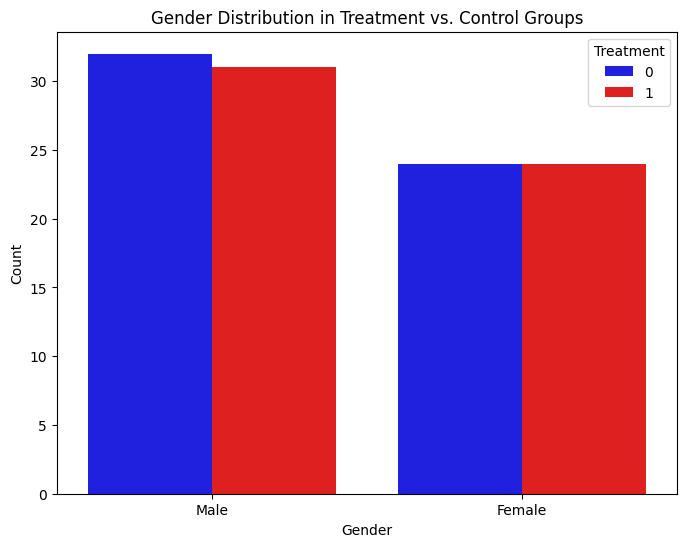

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(x="gender", hue="treatment", data=df_merged, palette=["blue", "red"])
plt.title("Gender Distribution in Treatment vs. Control Groups")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.legend(title="Treatment")
plt.show()


## PROF APPROVED - Likely Purchase by Treatment Group

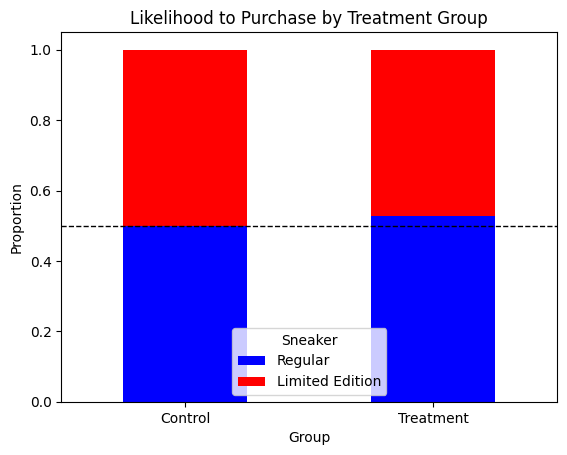

In [ ]:
# Sneaker B was limited editionn in the control...want to see if more people chose Sneaker B across groups

prop = df_merged.groupby("treatment")["likely_purchase"].value_counts(normalize = True).unstack() # normalize to see percent/proportion

prop.plot(kind="bar", stacked=True, color=["blue", "red"])
plt.xticks(ticks=[0, 1], labels=["Control", "Treatment"])
plt.xlabel("Group")
plt.xticks(rotation=360)
plt.ylabel("Proportion")
plt.title("Likelihood to Purchase by Treatment Group")
plt.legend(title="Sneaker", labels=["Regular", "Limited Edition"], loc="lower center")
plt.axhline(y=0.5, color="black", linestyle="--", linewidth=1)  # to see where 0.5 is (AKA 50/50 split)
plt.show()


We can see that there was a fairly even split in the Control Group (with labels) between choosing Limited Edition and Regular. However, in the Treatment Group (no labels), we can see a higher proportion of people chose the regular shoe (Sneaker A) over the limted edition one (Sneaker B).

## Average Resale Intentions by Treatment Group ... eh

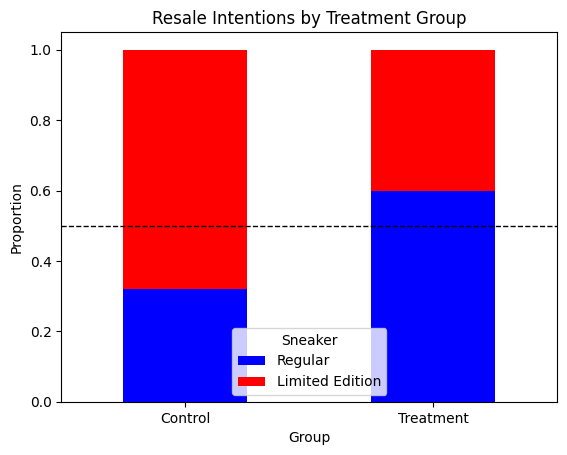

In [ ]:
# Sneaker B was limited editionn in the control...want to see if more people chose Sneaker B across groups

prop2 = df_merged.groupby("treatment")["resale_intent"].value_counts(normalize = True).unstack() # normalize to see percent/proportion

prop2.plot(kind="bar", stacked=True, color=["blue", "red"])
plt.xticks(ticks=[0, 1], labels=["Control", "Treatment"])
plt.xlabel("Group")
plt.xticks(rotation=360)
plt.ylabel("Proportion")
plt.title("Resale Intentions by Treatment Group")
plt.legend(title="Sneaker", labels=["Regular", "Limited Edition"], loc="lower center")
plt.axhline(y=0.5, color="black", linestyle="--", linewidth=1)  # to see where 0.5 is (AKA 50/50 split)
plt.show()


We can see that there more people would resell the shoe if it was explicitly labeled Limted Edition in the Control Group (with labels). In contrast, we can see a higher proportion of people chose the regular shoe (Sneaker A) over the limted edition one (Sneaker B) for resale purposes in the Treatment Group (no labels),

## Same Price Pick by Treatment Group

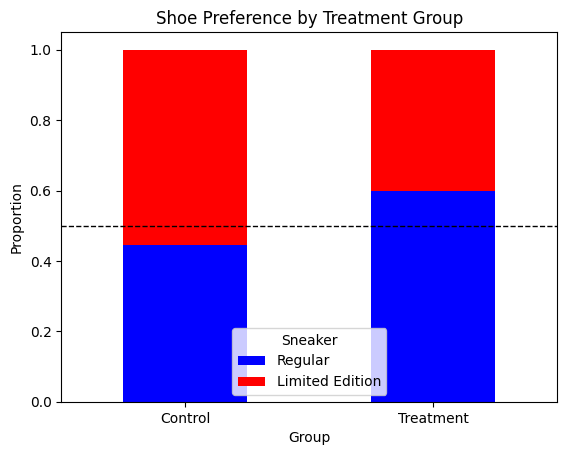

In [ ]:
# Sneaker B was limited editionn in the control...want to see if more people chose Sneaker B across groups

prop3 = df_merged.groupby("treatment")["choice_preference"].value_counts(normalize = True).unstack() # normalize to see percent/proportion

prop3.plot(kind="bar", stacked=True, color=["blue", "red"])
plt.xticks(ticks=[0, 1], labels=["Control", "Treatment"])
plt.xlabel("Group")
plt.xticks(rotation=360)
plt.ylabel("Proportion")
plt.title("Shoe Preference by Treatment Group")
plt.legend(title="Sneaker", labels=["Regular", "Limited Edition"], loc="lower center")
plt.axhline(y=0.5, color="black", linestyle="--", linewidth=1)  # to see where 0.5 is (AKA 50/50 split)
plt.show()


We can see that when both shoes are priced the same there was a substantial split in the Control Group (with labels) where more respondants would choose a limited edition sneakers over regular ones. In contrast, the Treatment Group (no labels), has a higher proportion of people more likely to choose a regular sneaker over a limited edition one when they're priced the same.

# Statistical Analysis

## Randomization Check

In [ ]:
# count: treatment and control observations
treatment_count = (df_merged["treatment"] == 1).sum()
control_count = (df_merged["treatment"] == 0).sum()

# TOTAL count
total_count = treatment_count + control_count

# 50% treatment, 50% control
value = 0.5

count = np.array([treatment_count])  # Count of treatment group
nobs = np.array([total_count])  # Total sample size

stat, pval = proportions_ztest(count, nobs, value=value)

pval = float(pval)  # convert from array to float

alpha = 0.05
if pval < alpha:
    print(f"p-value: {pval:.4f}: treatment and control groups are NOT properly randomized.")
else:
    print(f"p-value: {pval:.4f} → treatment and control groups are properly randomized.")


p-value: 0.9244 → treatment and control groups are properly randomized.


<ipython-input-112-00f76ab3afbc>:16: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pval = float(pval)  # convert from array to float


## T-Test

In [ ]:
# t-test for our primary area of interest (AKA more likely to purchase)


treated= df_merged[df_merged["treatment"] == 1]["likely_purchase"]
control = df_merged[df_merged["treatment"] == 0]["likely_purchase"]

t_test = pg.ttest(treated, control,
                  paired=False,
                  alternative='two-sided')

t_test


,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,-0.284938,108.969026,two-sided,0.776233,"[-0.22, 0.16]",0.054092,0.209,0.059187


We fail to reject the null hypothesis. There isn't enough information to conclude that the specific indicator or labeling of items being "Limited Edition" affects an individual's likelihood to purchase that item.

## Cohen's D & Power Analysis

In [ ]:
effect_size = pg.compute_effsize(treated, control, eftype='cohen')  # Google!
n = len(treated)
alpha = 0.05

power = TTestIndPower().solve_power(effect_size = effect_size,
                                     nobs1 = n,
                                     alpha = alpha,
                                     alternative = 'two-sided')

print(f"Effect Size (Cohen's D): {effect_size}")
print(f"Power achieved: {power}")

Effect Size (Cohen's D): -0.054091706111077435
Power achieved: 0.05910320975406555


The effect size is very close to 0, which suggests that the absence of labels does not have a meaningful impact on purchasing behavior. The statistical power is *very* low, meaning our study failes to detect a real effect almost 94% of the time (5.9% of time it's correct). This could be explained by the small sample and effect sizes.

## Regression Models

### Model 1: Purchase Intent

In [ ]:
# Goal: Check if being in the treatment group influences which sneaker people purchase

model1 = smf.ols("likely_purchase ~ treatment", data=df_merged).fit()
Stargazer([model1])

**Conclusion:** Removing "limited edition" labels does not have a statistically significant impact on the likelihood of people purchasing the sneakers.

* Coefficient: suggests a very small negative relationship between treatment and respondant's likelihood to purchase

* P-Value: effect is not statistically significant



### Model 2: Purchase Intent in Men & Women

In [ ]:
# Goal: Check if gender affects sneaker choice

model2 = smf.ols("likely_purchase ~ treatment + C(gender)", data=df_merged).fit()
Stargazer([model2])

**Conclusion:** Gender has a significant impact, with males being statistically more likely to purchase the sneakers than females

* Gender Coefficient: males are 0.233 units more likely to purchase than females, on average

* Treatment Coefficient: suggest a very small negative relationship between the treatment group and the likelihood of purchase

* P-Values: treatment does not significantly influence purchasing behavior, BUT gender has a meaningful impact on purchasing behavior

### Model 3: Resale Intent

In [ ]:
# Goal: See if the treatment group is more likely to resell their sneakers

model3 = smf.ols("resale_intent ~ treatment", data=df_merged).fit()
Stargazer([model3])

**Conclusion:** Removing "limited edition" labels decreases their potential for resale

* Coefficient: indicates a negative relationship with the likelihood of reselling when the limited edition shoe is not identified

* P-Value: effect is statistically significant

### Model 4: Willingness to Pay

In [ ]:
# Goal: See if treatment influences how much people are willing to pay

model4 = smf.ols("willingness_to_pay ~ treatment", data=df_merged).fit()
Stargazer([model4])

**Conclusion:** Removing "limited edition" labels does not significantly affect price preference or willingness to pay


* Coefficient: indicates a very small, negative relationship with price preference when the limited edition shoe is not identified

* P-Value: effect is not statistically significant

### Model 5: Price Sensitivity

In [ ]:
# Goal: Check if people in the treatment group are more likely to pay extra for premium materials

model5 = smf.ols("price_sensitivity ~ treatment", data=df_merged).fit()
Stargazer([model5])

**Conclusion:** Removing "limited edition" labels does not significantly affect the likelihood of paying more for premium materials


* Coefficient: indicates a small, positive relationship with paying more even when the limited edition shoe is not identified

* P-Value: effect is not statistically significant

### Model 6: Availability Influence

In [ ]:
# Goal: Check if the treatment makes people prefer limited edition products more

model6 = smf.ols("choice_preference ~ treatment", data=df_merged).fit()
Stargazer([model6])

**Conclusion:** Removing "limited edition" labels does not have a meaningful impact on shoe preference.

* Coefficient: indicates a negative relationship with shoe preference when limited edition shoe is not identified

* P-Value: effect is not statistically significant

### Model 7: Past Shopping Behavior

In [ ]:
# Goal: Check if the treatment creates a sense of urgency for people to purchase

model7 = smf.ols("past_shopping_behavior ~ treatment", data=df_merged).fit()
Stargazer([model7])

**Conclusion:** Removing "limited edition" labels does not have a significant effect on past shopping behavior, such as waiting in line or preordering for new releases.

* Coefficient: indicates a slight negative relationship with sense of urgency to purchase when limited edition shoe is not identified

* P-Value: effect is not statistically significant

# FOR REPORT

## Average Treatment Effects

In [ ]:
Stargazer([model1, model3, model4])

*Model 1*

**Conclusion:** Removing "limited edition" labels does not have a statistically significant impact on the likelihood of people purchasing the sneakers.

* Coefficient: suggests a very small negative relationship between treatment and respondant's likelihood to purchase

* P-Value: effect is not statistically significant

*Model 3*

**Conclusion:** Removing "limited edition" labels decreases their potential for resale

* Coefficient: indicates a negative relationship with the likelihood of reselling when the limited edition shoe is not identified

* P-Value: effect is statistically significant

*Model 4*

**Conclusion:** Removing "limited edition" labels does not significantly affect willingness to pay


* Coefficient: indicates a very small, negative relationship with price preference when the limited edition shoe is not identified

* P-Value: effect is not statistically significant

## Heterogeneous Treatment Effects

In [ ]:
Stargazer([model2, model7])

*Model 2*

**Conclusion:** Gender has a significant impact, with males being statistically more likely to purchase the sneakers than females

* Gender Coefficient: males are 0.233 units more likely to purchase than females, on average

* Treatment Coefficient: suggest a very small negative relationship between the treatment group and the likelihood of purchase

* P-Values: treatment does not significantly influence purchasing behavior, BUT gender has a meaningful impact on purchasing behavior*

*Model 7*

**Conclusion:** Removing "limited edition" labels does not have a significant effect on past shopping behavior, such as waiting in line or preordering for new releases.

* Coefficient: indicates a slight negative relationship with sense of urgency to purchase when limited edition shoe is not identified

* P-Value: effect is not statistically significant